In [95]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [64]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\ImmigrantFlow.csv') 
print(list(set(df['Migration Flow'])))

['Inward migration - All', 'Net migration', 'Outward migration']


In [65]:
flow = "Inward migration - All"
age = "All ages"
country = "Brazil"
filtered_df = df[df['Age Group']==age]
filtered_df = filtered_df[filtered_df['Migration Flow']==flow]
filtered_df = filtered_df[filtered_df['Migration Calculation Method']=="Base migration calculation method"]
filtered_df['Quarter'] = filtered_df['Quarter'].apply(lambda x: x[2:4]+"' "+x[4:])
#filtered_df = filtered_df[(filtered_df['Nationality']!="Ireland")&(filtered_df['Nationality']!="All nationalities")]
# print(filtered_df)

In [66]:
def changeName(country):
    switch = {
        "United Kingdom of Great Britain and Northern Ireland":"UK",
        "Other nationalities (3)":"Other",
        "EU14 excl Irl (countries in the EU pre 2004 excluding UK & Ireland)":"EU14",
        "EU15 to EU27 (accession countries joined post 2004)":"EU15-27"
    }
    if country not in switch:
        return country
    else:
        return switch[country]
filtered_df['Nationality'] = filtered_df['Nationality'].apply(changeName)
brazil_df = filtered_df[filtered_df['Nationality']=="Brazil"]
india_df = filtered_df[filtered_df['Nationality']=="India"]
ukraine_df = filtered_df[filtered_df['Nationality']=="Ukraine"]

In [67]:
print(filtered_df)

                Statistic Label Quarter          Migration Flow Age Group  \
72    Estimated migration flows  22' Q3  Inward migration - All  All ages   
74    Estimated migration flows  22' Q3  Inward migration - All  All ages   
76    Estimated migration flows  22' Q3  Inward migration - All  All ages   
78    Estimated migration flows  22' Q3  Inward migration - All  All ages   
80    Estimated migration flows  22' Q3  Inward migration - All  All ages   
...                         ...     ...                     ...       ...   
1970  Estimated migration flows  24' Q2  Inward migration - All  All ages   
1972  Estimated migration flows  24' Q2  Inward migration - All  All ages   
1974  Estimated migration flows  24' Q2  Inward migration - All  All ages   
1976  Estimated migration flows  24' Q2  Inward migration - All  All ages   
1978  Estimated migration flows  24' Q2  Inward migration - All  All ages   

            Nationality       Migration Calculation Method    UNIT    VALUE

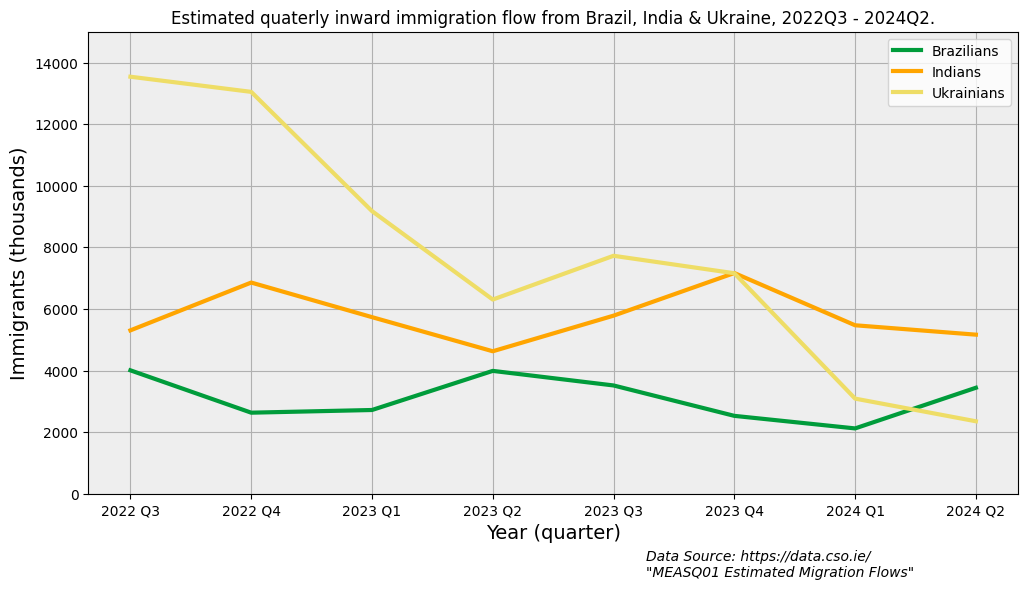

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

brazil_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", color="#009C3B", linewidth=3, ax=ax, label="Brazilians")
india_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", color="#FFA500", linewidth=3, ax=ax, label="Indians")
ukraine_df.plot(x="Quarter", y="VALUE", kind="line", marker="None", linestyle="-", color="#ED6", linewidth=3, ax=ax, label="Ukrainians")

title_string = "Estimated quaterly inward immigration flow from Brazil, India & Ukraine, 2022Q3 - 2024Q2."

ax.set_title(title_string)
ax.set_xlabel("Year (quarter)", fontsize=14)
ax.set_ylabel("Immigrants (thousands)", fontsize=14)
ax.set_ylim(0, 15000)
ax.set_facecolor('#EEEEEE')
ax.grid(True)
plt.text(0.6, -0.18, "Data Source: https://data.cso.ie/\n\"MEASQ01 Estimated Migration Flows\" ", ha='left',
         transform=ax.transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'Immigrant-flow-BIU.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()

In [116]:
filtered_df = df[df['Age Group']==age]
filtered_df = filtered_df[filtered_df['Migration Flow']=="Net migration"]
filtered_df = filtered_df[filtered_df['Migration Calculation Method']=="Base migration calculation method"]
filtered_df['Quarter'] = filtered_df['Quarter'].apply(lambda x: x[2:4]+"' "+x[4:])

In [117]:
filtered_df['Nationality'] = filtered_df['Nationality'].apply(changeName)
ireland_df = filtered_df[filtered_df['Nationality']=="Ireland"]

In [118]:
print(ireland_df)

                Statistic Label Quarter Migration Flow Age Group Nationality  \
252   Estimated migration flows  22' Q3  Net migration  All ages     Ireland   
522   Estimated migration flows  22' Q4  Net migration  All ages     Ireland   
792   Estimated migration flows  23' Q1  Net migration  All ages     Ireland   
1062  Estimated migration flows  23' Q2  Net migration  All ages     Ireland   
1332  Estimated migration flows  23' Q3  Net migration  All ages     Ireland   
1602  Estimated migration flows  23' Q4  Net migration  All ages     Ireland   
1872  Estimated migration flows  24' Q1  Net migration  All ages     Ireland   
2142  Estimated migration flows  24' Q2  Net migration  All ages     Ireland   

           Migration Calculation Method    UNIT    VALUE  
252   Base migration calculation method  Number  -1135.0  
522   Base migration calculation method  Number -16611.0  
792   Base migration calculation method  Number -10259.0  
1062  Base migration calculation method  Nu

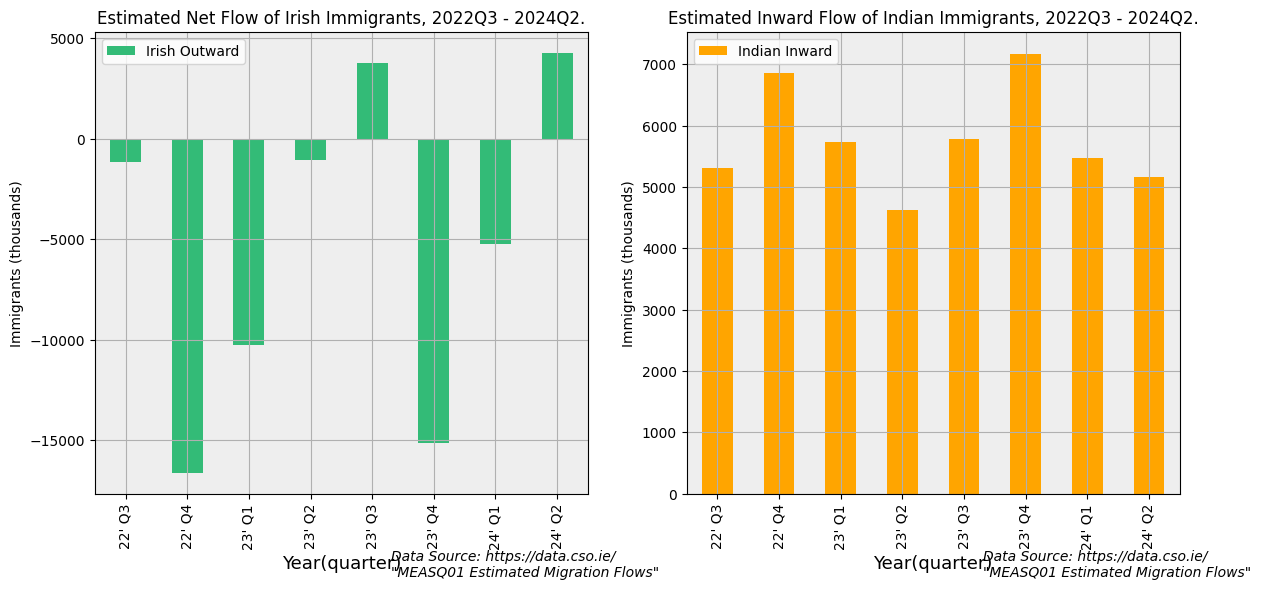

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ireland_df.plot(x="Quarter", y="VALUE", kind="bar", color="#3B7", ax=ax[0], label="Irish Outward")
india_df.plot(x="Quarter", y="VALUE", kind="bar", color="#FFA500", ax=ax[1], label="Indian Inward")

ax[0].set_title("Estimated Net Flow of Irish Immigrants, 2022Q3 - 2024Q2.")
ax[0].set_xlabel("Year(quarter)", fontsize=13)
ax[0].set_ylabel("Immigrants (thousands)")
#ax[0].set_ylim(0)
ax[0].set_facecolor('#EEEEEE')
ax[0].grid(True)
plt.text(0.6, -0.18, "Data Source: https://data.cso.ie/\n\"MEASQ01 Estimated Migration Flows\" ", ha='left',
         transform=ax[0].transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

ax[1].set_title("Estimated Inward Flow of Indian Immigrants, 2022Q3 - 2024Q2.")
ax[1].set_xlabel("Year(quarter)", fontsize=13)
ax[1].set_ylabel("Immigrants (thousands)")
#ax[1].set_ylim(0)
ax[1].set_facecolor('#EEEEEE')
ax[1].grid(True)
plt.text(0.6, -0.18, "Data Source: https://data.cso.ie/\n\"MEASQ01 Estimated Migration Flows\" ", ha='left',
         transform=ax[1].transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})


save_fig = 'ImmigrantFlowIrishIndianBar.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()

In [140]:
country="Ukraine"
filtered_df = df[df['Age Group']==age]
filtered_df = filtered_df[filtered_df['Migration Flow']=="Net migration"]
filtered_df = filtered_df[filtered_df['Migration Calculation Method']=="Base migration calculation method"]
filtered_df['Quarter'] = filtered_df['Quarter'].apply(lambda x: x[2:4]+"' "+x[4:])

filtered_df['Nationality'] = filtered_df['Nationality'].apply(changeName)
country_df = filtered_df[filtered_df['Nationality']==country]

In [141]:
merged = pd.merge(
    ireland_df[['Quarter', 'VALUE']].rename(columns={'VALUE': 'Ireland'}),
    country_df[['Quarter', 'VALUE']].rename(columns={'VALUE': country}),
    on='Quarter',
    how='inner'  # or 'outer' if you want to include missing quarters
)
print(merged)

  Quarter  Ireland  Ukraine
0  22' Q3  -1135.0  13511.0
1  22' Q4 -16611.0  12258.0
2  23' Q1 -10259.0   8060.0
3  23' Q2  -1060.0   4908.0
4  23' Q3   3747.0   5956.0
5  23' Q4 -15125.0   4981.0
6  24' Q1  -5245.0   1287.0
7  24' Q2   4277.0    572.0


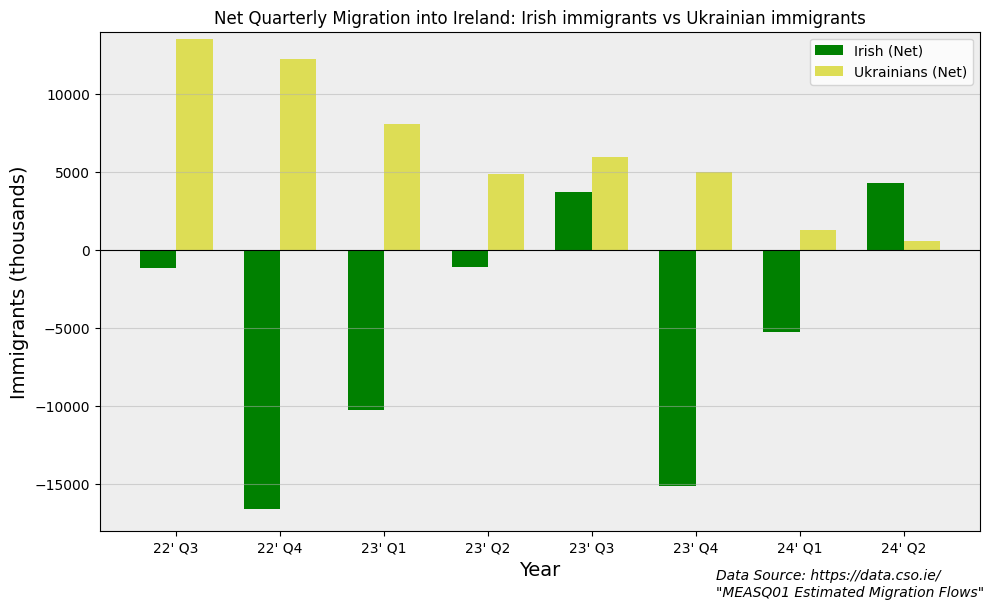

In [144]:
x = np.arange(len(merged['Quarter']))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, merged['Ireland'], width, label='Irish (Net)', color='green')
plt.bar(x + width/2, merged['Ukraine'], width, label='Ukrainians (Net)', color='#DD5')
plt.axhline(0, color='black', linewidth=0.8)
plt.gca().set_facecolor('#EEEEEE')

plt.xticks(x, merged['Quarter'], rotation=0)
plt.ylabel('Immigrants (thousands)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.title('Net Quarterly Migration into Ireland: Irish immigrants vs Ukrainian immigrants')
plt.ylim(-18000, 14000)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)

plt.text(0.7, -0.13, "Data Source: https://data.cso.ie/\n\"MEASQ01 Estimated Migration Flows\" ",
         transform=plt.gca().transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'ImmigrantFlowIrishUkraineBarTogether.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()
